# Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pickle
import scipy
from ode_dynamics import ln_dynamics

In [ ]:

    
    # def __setattr__(self, name, value):
    #     print(name,value)
    #     object.__setattr__(self,name,value)
    #     self.update_params()
    #     self.update_y()

# df/dt=Mf+k

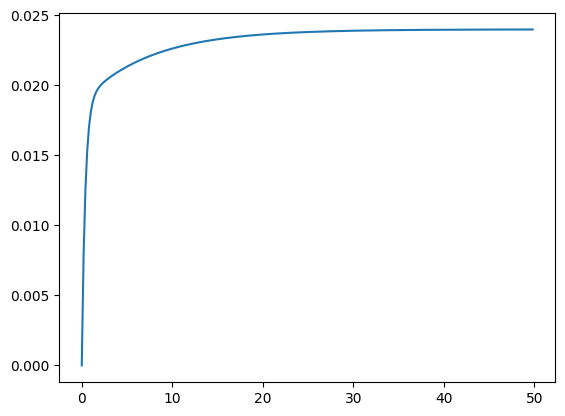

In [79]:
simulation=ln_dynamics()
M0=simulation.M.copy()
w0=simulation.w.copy()

t_range=np.arange(0,50,0.2)
traj=simulation.evolve(t_range)

plt.plot(t_range,traj[:,1])

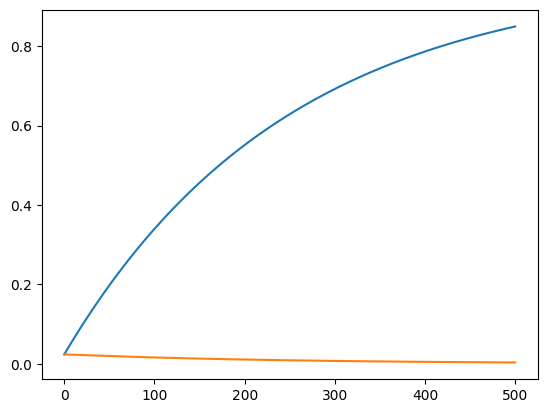

In [92]:
simulation=ln_dynamics()
simulation.update_params()
simulation.f=simulation.w
simulation.fac_e_i=2.
simulation.ti=9999.

t_range=np.arange(0,500,0.2)
traj_one_side=simulation.evolve(t_range)

traj=traj_one_side
plt.plot(t_range,traj[:,1])
plt.plot(t_range,traj[:,2])

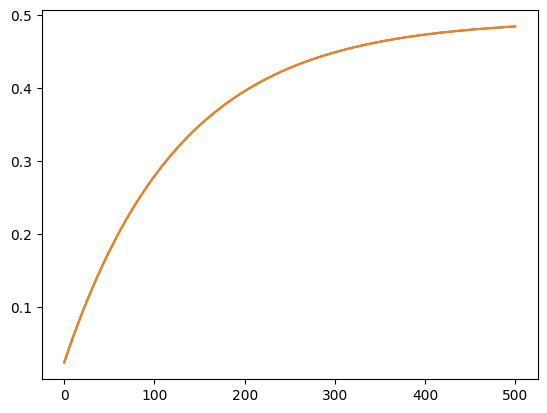

In [93]:
simulation=ln_dynamics()
simulation.update_params()
simulation.f=simulation.w
simulation.fac_e_i=2.
simulation.ti=9999.
simulation.fac_e_j=2.
simulation.tj=9999.

traj_two_side=simulation.evolve(t_range)

traj=traj_two_side
plt.plot(t_range,traj[:,1])
plt.plot(t_range,traj[:,2])

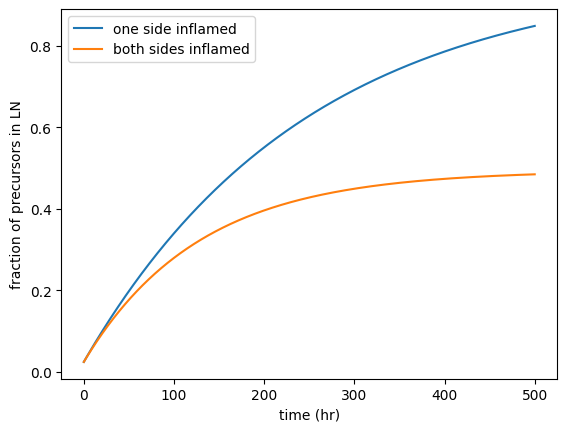

In [95]:
plt.plot(t_range,traj_one_side[:,1],label='one side inflamed')
plt.plot(t_range,traj_two_side[:,1],label='both sides inflamed')
plt.xlabel('time (hr)')
plt.ylabel('fraction of precursors in LN')
plt.legend()

Text(0, 0.5, 'fraction of naive precursors')

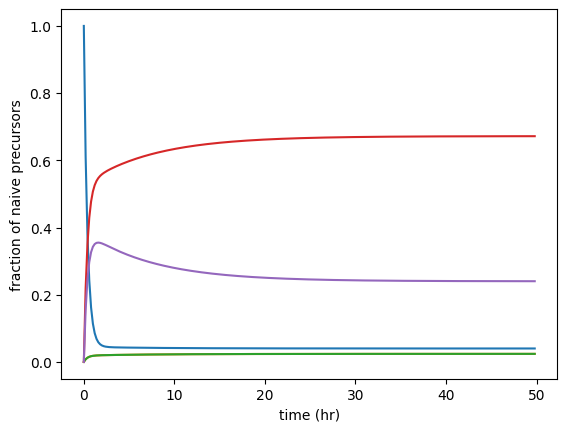

In [8]:
# evolution from all cells in blood

t_range=np.arange(0,50,0.2)

# traj = np.array([(V @ (y*np.exp(lam*t)) + w) for t in t_range])

simulation=ln_dynamics()
traj = simulation.evolve(t_range)

for i in range(4):
    plt.plot(t_range,traj[:,i],label=simulation.row_labels[i])

plt.plot(t_range,1-traj.sum(axis=1),label='spleen')
plt.xlabel('time (hr)')
plt.ylabel('fraction of naive precursors')

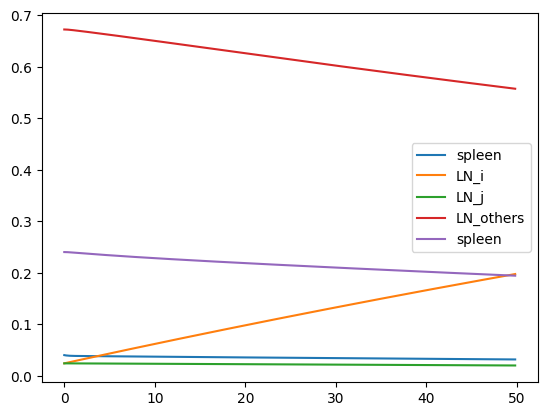

In [14]:
# evolution from steady state, i inflamed only

simulation=ln_dynamics()
simulation.equilibrate()

simulation.fac_e_i=2 
simulation.ti=9999.

# e_i=3*(1/n_ln)
# ti=999.

# M=np.array([[-e_i-e_j-e_oln-e_sp-1/tsp,1/ti-1/tsp,1/tj-1/tsp,1/tln-1/tsp],
#             [e_i,-1/ti,0,0],
#             [e_j,0,-1/tj,0],
#             [e_oln,0,0,-1/tln]])

# f0=- np.linalg.pinv(M0) @ k
# lam, V = np.linalg.eig(M)
# w= - np.linalg.pinv(M) @ k
# y= np.linalg.pinv(V) @ (f0 - w)

t_range=np.arange(0,50,0.2)

traj = simulation.evolve(t_range)

for i in range(4):
    plt.plot(t_range,traj[:,i],label=simulation.row_labels[i])

plt.plot(t_range,1-traj.sum(axis=1),label='spleen')

plt.legend()

traj_one_side=traj[:,1]

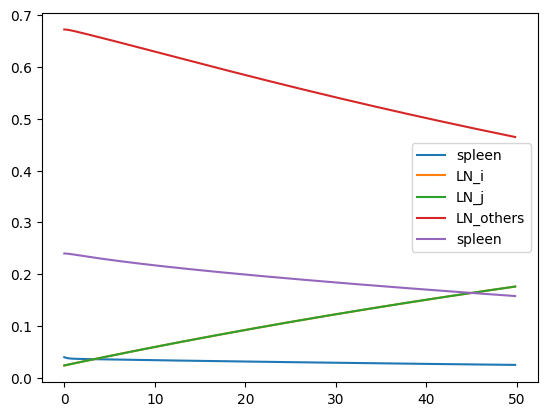

In [15]:
# evolution from steady state, i j both inflamed

simulation=ln_dynamics()
simulation.equilibrate()

simulation.fac_e_i=2 
simulation.ti=9999.
simulation.fac_e_j=2 
simulation.tj=9999.

# e_i=3*(1/n_ln)
# ti=999.
# e_j=3*(1/n_ln)
# tj=999.

# M=np.array([[-e_i-e_j-e_oln-e_sp-1/tsp,1/ti-1/tsp,1/tj-1/tsp,1/tln-1/tsp],
#             [e_i,-1/ti,0,0],
#             [e_j,0,-1/tj,0],
#             [e_oln,0,0,-1/tln]])

# f0=- np.linalg.pinv(M0) @ k
# lam, V = np.linalg.eig(M)
# w= - np.linalg.pinv(M) @ k
# y= np.linalg.pinv(V) @ (f0 - w)

t_range=np.arange(0,50,0.2)

traj = simulation.evolve(t_range)

# traj = np.array([(V @ (y*np.exp(lam*t)) + w) for t in t_range])

for i in range(4):
    plt.plot(t_range,traj[:,i],label=simulation.row_labels[i])

plt.plot(t_range,1-traj.sum(axis=1),label='spleen')

plt.legend()

traj_two_side=traj[:,1]

(0.0, 0.20602127767930165)

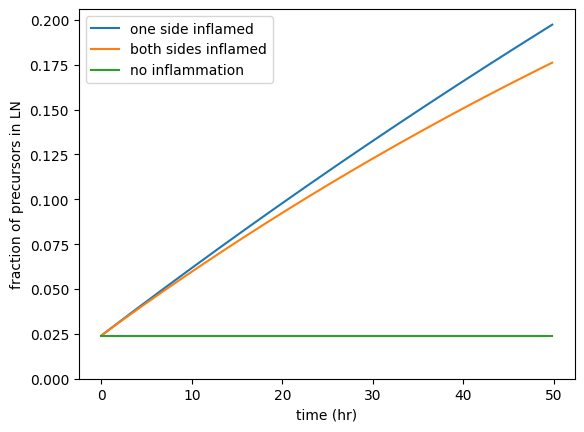

In [17]:
simulation=ln_dynamics()
simulation.equilibrate()

t_range=np.arange(0,50,0.2)

traj = simulation.evolve(t_range)

traj_no_inflam=traj[:,1]

plt.plot(t_range,traj_one_side,label='one side inflamed')
plt.plot(t_range,traj_two_side,label='both sides inflamed')
plt.plot(t_range,traj_no_inflam,label='no inflammation')
plt.legend()
plt.xlabel('time (hr)')
plt.ylabel('fraction of precursors in LN')
plt.ylim(0)

(0.0, 0.5070823984468998)

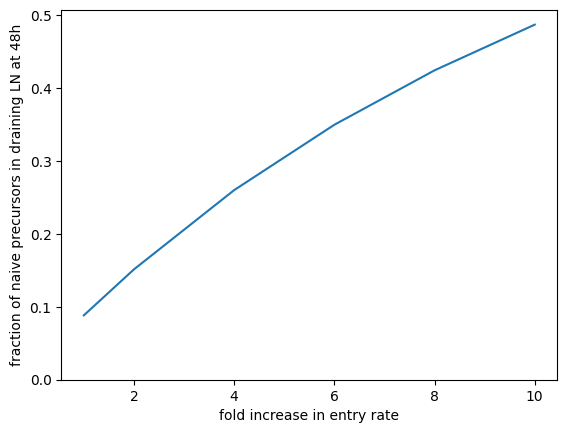

In [62]:
fac_range=np.array([1.,2.,4.,6.,8.,10.])
container=np.zeros_like(fac_range)
for i,fac in enumerate(fac_range): 
    simulation=ln_dynamics(n_ln=39)
    simulation.equilibrate()

    simulation.fac_e_i=fac
    simulation.ti=9999.
    t=48

    container[i]=simulation.evolve(t)[1]

plt.plot(fac_range,container)
plt.xlabel('fold increase in entry rate')
plt.ylabel('fraction of naive precursors in draining LN at 48h')
plt.ylim(0,None)

[0.03649635 0.0190904  0.0190904  0.70634475]


(0.0, 0.23294383172784391)

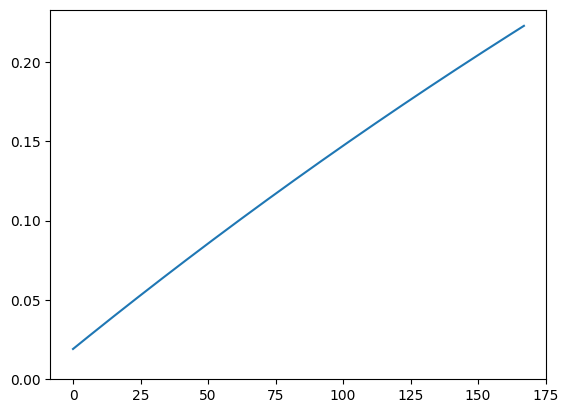

In [77]:
simulation=ln_dynamics(n_ln=39,ti=13.6,tj=13.6,tln=13.6)
simulation.equilibrate()
print(simulation.f)
simulation.ti=9999.
t_range=np.arange(0,168,1)

traj=simulation.evolve(t_range)

plt.plot(t_range,traj[:,1])
plt.ylim(0,None)

(0.0, 0.9906190440589836)

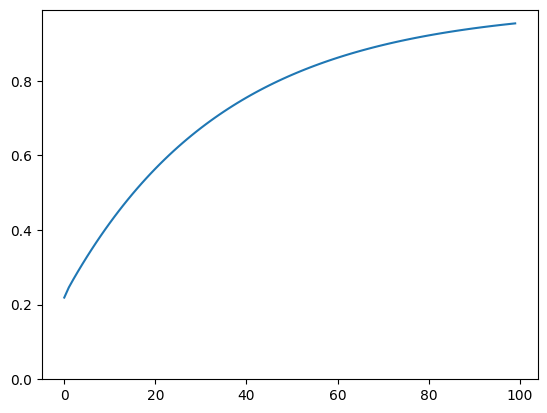

In [80]:
simulation=ln_dynamics(n_ln=39.,ti=13.6,tj=13.6,tln=13.6)
simulation.equilibrate()
simulation.tsp=9999.
t_range=np.arange(0,100,1)

traj=simulation.evolve(t_range)

plt.plot(t_range,1-traj.sum(axis=1))
plt.ylim(0,None)


for spleen infection dynamics agree with paper

39.0
19.5
6.5
4.333333333333333


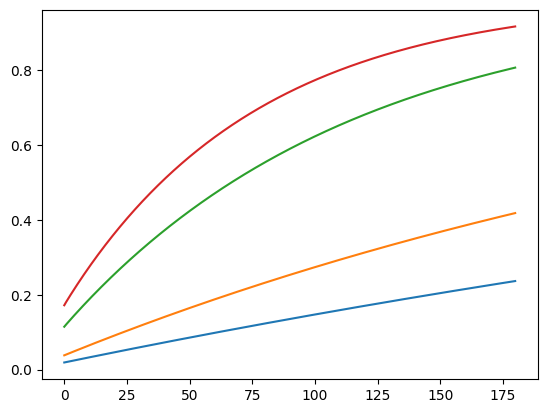

In [83]:
frac_arr=np.array([1/39,2/39,6/39,9/39])
# frac_arr=np.array([1/39,2/39])
for frac_active in frac_arr:
    simulation=ln_dynamics(n_ln=1/frac_active,ti=13.6,tj=13.6,tln=13.6)
    print(simulation.n_ln)
    simulation.equilibrate()
    simulation.ti=9999.
    t_range=np.arange(0,180,0.1)

    traj=simulation.evolve(t_range)

    plt.plot(t_range,traj[:,1])

# plt.ylim(0,1)

In [65]:
traj[:,1]

array([0.17181359, 0.17305507, 0.1742623 , ..., 0.91582949, 0.91593123,
       0.91603283])

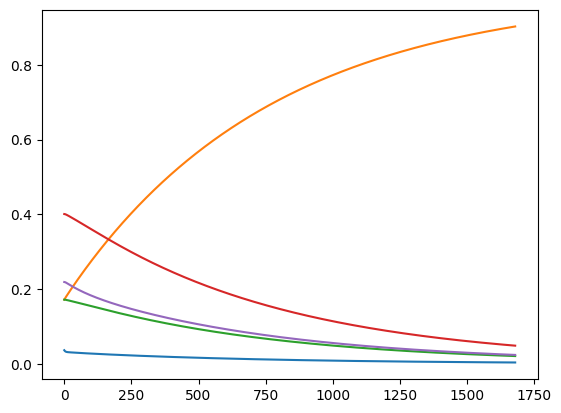

In [57]:
for i in range(4):
    plt.plot(traj[:,i])
plt.plot(1-traj.sum(axis=1))

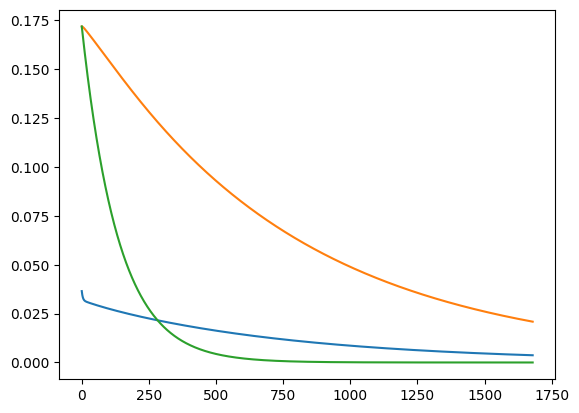

In [60]:
plt.plot(traj[:,0])
plt.plot(traj[:,2])
simulation_alt=ln_dynamics(n_ln=1/frac_active,ti=13.6,tj=13.6,tln=13.6)
simulation_alt.equilibrate()
simulation_alt.fac_e_j=0
traj_alt=simulation_alt.evolve(t_range)

plt.plot(traj_alt[:,2])

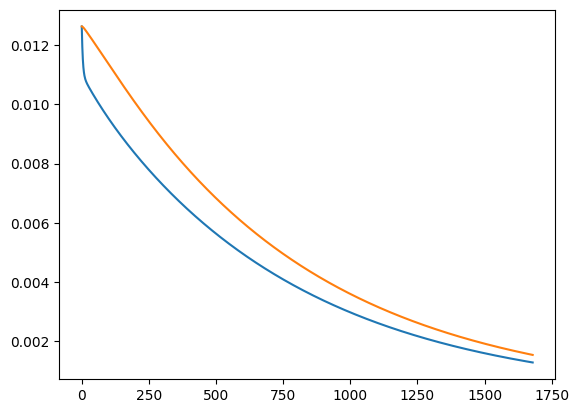

In [61]:
plt.plot(simulation.e_j*traj[:,0])
plt.plot(1/simulation.tj*traj[:,2])


In [74]:
sol.y.shape

(4, 123)

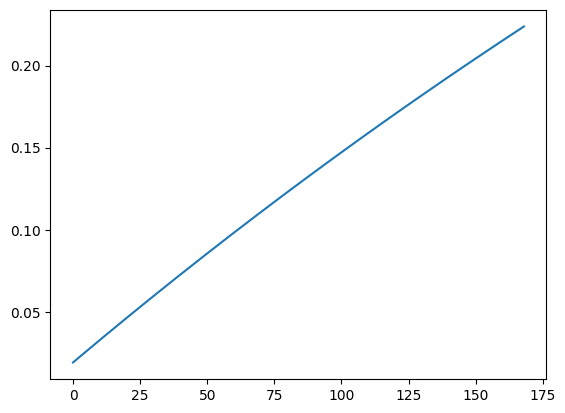

In [76]:
simulation=ln_dynamics(n_ln=39,ti=13.6,tj=13.6,tln=13.6)
simulation.equilibrate()
simulation.ti=9999
simulation.update_params()
sol=scipy.integrate.solve_ivp(lambda t,x:simulation.M @ x + simulation.k,(0,168),simulation.f)
plt.plot(sol.t,sol.y[1])

In [ ]:
lambda t,x:simulation.M @ x + simulation.y